<a href="https://colab.research.google.com/github/yana-g/graph-analysis/blob/main/02_Graph_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2. Temporal Analysis of the Israeli Actors Collaboration Graph

This notebook analyzes how the Israeli actors collaboration network changes over time.

The data is divided into three non-overlapping periods:

- **Period A:** Until 1969
- **Period B:** 1970–1989
- **Period C:** 1990–Today

For each period, the notebook calculates graph size, density, clustering, connectivity, radius, diameter, and degree-distribution measures. All actors listed in the movie dataset are added as nodes, including isolated actors.

### 1. Imports

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

### 2. Load and Validate Data

The analysis uses the cleaned files created in Part 1. Both files are required because `movies_with_actors.csv` preserves isolated actors, while `actor_edges.csv` contains the collaboration records.

In [2]:
MOVIES_FILE = Path("movies_with_actors.csv")
EDGES_FILE = Path("actor_edges.csv")

missing_files = [
    str(path)
    for path in (MOVIES_FILE, EDGES_FILE)
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Missing required input files: "
        + ", ".join(missing_files)
    )

movies_df = pd.read_csv(
    MOVIES_FILE,
    encoding="utf-8-sig"
)

edges_df = pd.read_csv(
    EDGES_FILE,
    encoding="utf-8-sig"
)

required_movie_columns = {
    "page_id",
    "movie_title",
    "year"
}

required_edge_columns = {
    "actor_1",
    "actor_2",
    "movie_title",
    "year",
    "page_id"
}

missing_movie_columns = (
    required_movie_columns
    - set(movies_df.columns)
)

missing_edge_columns = (
    required_edge_columns
    - set(edges_df.columns)
)

if missing_movie_columns:
    raise ValueError(
        "Missing movie columns: "
        + ", ".join(sorted(missing_movie_columns))
    )

if missing_edge_columns:
    raise ValueError(
        "Missing edge columns: "
        + ", ".join(sorted(missing_edge_columns))
    )

movies_df["year"] = pd.to_numeric(
    movies_df["year"],
    errors="coerce"
)

edges_df["year"] = pd.to_numeric(
    edges_df["year"],
    errors="coerce"
)

movies_df = (
    movies_df
    .dropna(subset=["page_id", "movie_title", "year"])
    .drop_duplicates(subset="page_id")
    .copy()
)

edges_df = (
    edges_df
    .dropna(
        subset=[
            "actor_1",
            "actor_2",
            "movie_title",
            "year",
            "page_id"
        ]
    )
    .copy()
)

movies_df["year"] = movies_df["year"].astype(int)
edges_df["year"] = edges_df["year"].astype(int)

actor_columns = sorted(
    [
        column
        for column in movies_df.columns
        if re.fullmatch(r"actor_\d+", column)
    ],
    key=lambda column: int(column.split("_")[1])
)

if not actor_columns:
    raise ValueError(
        "No actor columns matching actor_1, actor_2, ... were found."
    )

print("Movies:", len(movies_df))
print("Actor-pair film records:", len(edges_df))
print(
    "Year range:",
    movies_df["year"].min(),
    "-",
    movies_df["year"].max()
)
print("Actor columns:", actor_columns)

Movies: 1155
Actor-pair film records: 29374
Year range: 1960 - 2026
Actor columns: ['actor_1', 'actor_2', 'actor_3', 'actor_4', 'actor_5', 'actor_6', 'actor_7', 'actor_8', 'actor_9', 'actor_10']


### 3. Define Time Periods

The assignment boundaries are implemented without overlap:

- **Until 1969**
- **1970–1989**
- **1990–Today**

In [3]:
PERIODS = {
    "Until 1969": (None, 1969),
    "1970–1989": (1970, 1989),
    "1990–Today": (1990, None)
}

### 4. Helper Functions

In [4]:
def filter_by_period(
    dataframe,
    start_year=None,
    end_year=None
):
    """Return records inside one time period."""
    period_data = dataframe.copy()

    if start_year is not None:
        period_data = period_data[
            period_data["year"] >= start_year
        ]

    if end_year is not None:
        period_data = period_data[
            period_data["year"] <= end_year
        ]

    return period_data.copy()


def extract_movie_actors(row):
    """Return the unique cleaned actors listed for one movie."""
    actors = []
    seen = set()

    for column in actor_columns:
        actor = getattr(row, column)

        if pd.isna(actor):
            continue

        actor = re.sub(
            r"\s+",
            " ",
            str(actor)
        ).strip()

        if not actor:
            continue

        key = actor.casefold()

        if key in seen:
            continue

        seen.add(key)
        actors.append(actor)

    return actors


def build_period_graph(
    period_movies,
    period_edges
):
    """Build one undirected collaboration graph for a period."""
    graph = nx.Graph()

    # Add every actor, including actors who have no edge.
    for row in period_movies.itertuples(index=False):
        graph.add_nodes_from(
            extract_movie_actors(row)
        )

    # Add or update collaboration edges.
    for row in period_edges.itertuples(index=False):
        actor_1 = str(row.actor_1).strip()
        actor_2 = str(row.actor_2).strip()

        if (
            not actor_1
            or not actor_2
            or actor_1 == actor_2
        ):
            continue

        if graph.has_edge(actor_1, actor_2):
            graph[actor_1][actor_2]["weight"] += 1
            graph[actor_1][actor_2]["movies"].append(
                row.movie_title
            )
            graph[actor_1][actor_2]["years"].append(
                int(row.year)
            )
        else:
            graph.add_edge(
                actor_1,
                actor_2,
                weight=1,
                movies=[row.movie_title],
                years=[int(row.year)]
            )

    return graph


def calculate_graph_metrics(graph):
    """Calculate all metrics required by the assignment."""
    node_count = graph.number_of_nodes()
    edge_count = graph.number_of_edges()

    if node_count == 0:
        return {
            "nodes": 0,
            "edges": 0,
            "density": 0.0,
            "average_clustering": 0.0,
            "connected_components": 0,
            "isolated_nodes": 0,
            "largest_component_size": 0,
            "largest_component_share": 0.0,
            "radius_lcc": np.nan,
            "diameter_lcc": np.nan,
            "average_degree": 0.0,
            "maximum_degree": 0
        }

    degrees = [
        degree
        for _, degree in graph.degree()
    ]

    components = list(
        nx.connected_components(graph)
    )

    largest_nodes = max(
        components,
        key=len
    )

    largest_component = graph.subgraph(
        largest_nodes
    ).copy()

    if largest_component.number_of_nodes() <= 1:
        radius_lcc = 0
        diameter_lcc = 0
    else:
        radius_lcc = nx.radius(
            largest_component,
            usebounds=True
        )
        diameter_lcc = nx.diameter(
            largest_component,
            usebounds=True
        )

    return {
        "nodes": node_count,
        "edges": edge_count,
        "density": nx.density(graph),
        "average_clustering": nx.average_clustering(graph),
        "connected_components": len(components),
        "isolated_nodes": nx.number_of_isolates(graph),
        "largest_component_size": len(largest_nodes),
        "largest_component_share": len(largest_nodes) / node_count,
        "radius_lcc": radius_lcc,
        "diameter_lcc": diameter_lcc,
        "average_degree": float(np.mean(degrees)),
        "maximum_degree": int(max(degrees))
    }


def add_bar_labels(ax, decimals=0):
    """Add value labels to a vertical bar chart."""
    labels = []

    for patch in ax.patches:
        value = patch.get_height()

        if decimals == 0:
            labels.append(f"{value:.0f}")
        else:
            labels.append(f"{value:.{decimals}f}")

    ax.bar_label(
        ax.containers[0],
        labels=labels,
        padding=3,
        fontsize=9
    )

### 5. Build One Graph per Period

Radius and diameter are calculated on the largest connected component because these measures are not defined for a disconnected graph.

In [5]:
period_graphs = {}
period_movies = {}
period_edges = {}
metric_records = []

for period_name, (
    start_year,
    end_year
) in PERIODS.items():
    current_movies = filter_by_period(
        movies_df,
        start_year=start_year,
        end_year=end_year
    )

    current_edges = filter_by_period(
        edges_df,
        start_year=start_year,
        end_year=end_year
    )

    current_graph = build_period_graph(
        current_movies,
        current_edges
    )

    period_movies[period_name] = current_movies
    period_edges[period_name] = current_edges
    period_graphs[period_name] = current_graph

    metrics = calculate_graph_metrics(
        current_graph
    )

    metrics.update({
        "period": period_name,
        "films": current_movies["page_id"].nunique(),
        "actor_pair_records": len(current_edges)
    })

    metric_records.append(metrics)

metrics_df = (
    pd.DataFrame(metric_records)
    .set_index("period")
)

metrics_df.round(4)

,nodes,edges,density,average_clustering,connected_components,isolated_nodes,largest_component_size,largest_component_share,radius_lcc,diameter_lcc,average_degree,maximum_degree,films,actor_pair_records
period,,,,,,,,,,,,,,
Until 1969,217,1580,0.0674,0.7640,3,2,215,0.9908,3,5,14.5622,60,57,1751
1970–1989,851,7119,0.0197,0.7623,4,0,841,0.9882,3,5,16.7309,147,224,7749
1990–Today,2537,19304,0.0060,0.7679,60,18,2340,0.9223,4,7,15.2180,170,874,19874


### 6. Graph Metrics Summary

In [6]:
comparison_columns = [
    "films",
    "nodes",
    "edges",
    "density",
    "average_clustering",
    "connected_components",
    "isolated_nodes",
    "largest_component_size",
    "largest_component_share",
    "radius_lcc",
    "diameter_lcc",
    "average_degree",
    "maximum_degree"
]

comparison_df = (
    metrics_df[comparison_columns]
    .T
)

display(
    comparison_df.style.format({
        period: "{:.4f}"
        for period in comparison_df.columns
    })
)

period,Until 1969,1970–1989,1990–Today
films,57.0000,224.0000,874.0000
nodes,217.0000,851.0000,2537.0000
edges,1580.0000,7119.0000,19304.0000
density,0.0674,0.0197,0.0060
average_clustering,0.7640,0.7623,0.7679
connected_components,3.0000,4.0000,60.0000
isolated_nodes,2.0000,0.0000,18.0000
largest_component_size,215.0000,841.0000,2340.0000
largest_component_share,0.9908,0.9882,0.9223
radius_lcc,3.0000,3.0000,4.0000


### 7. Degree Distributions

The standard histograms show the number of actors at each degree range. The log-log plots make the long tail easier to inspect.

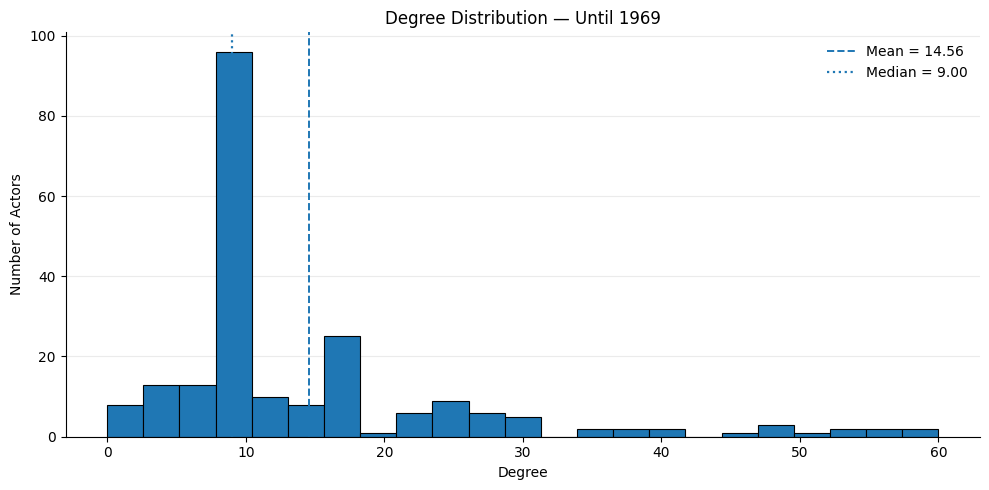

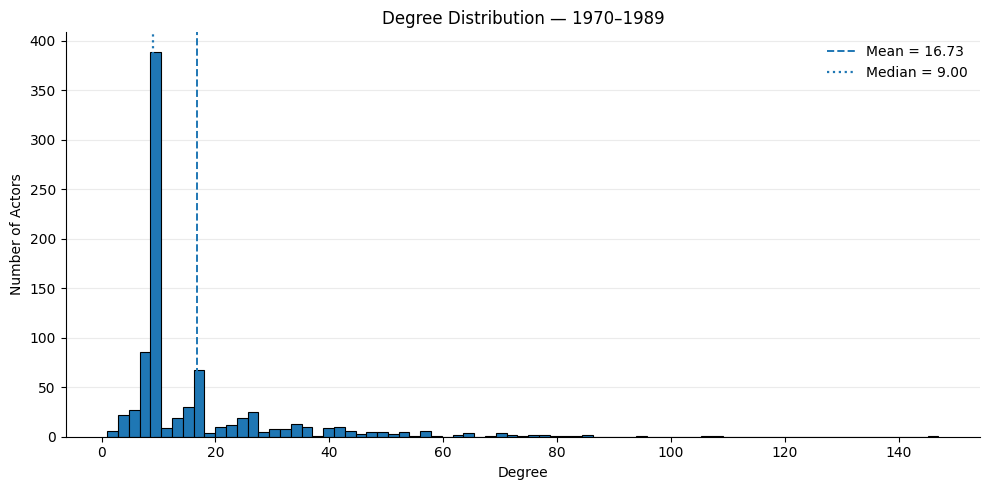

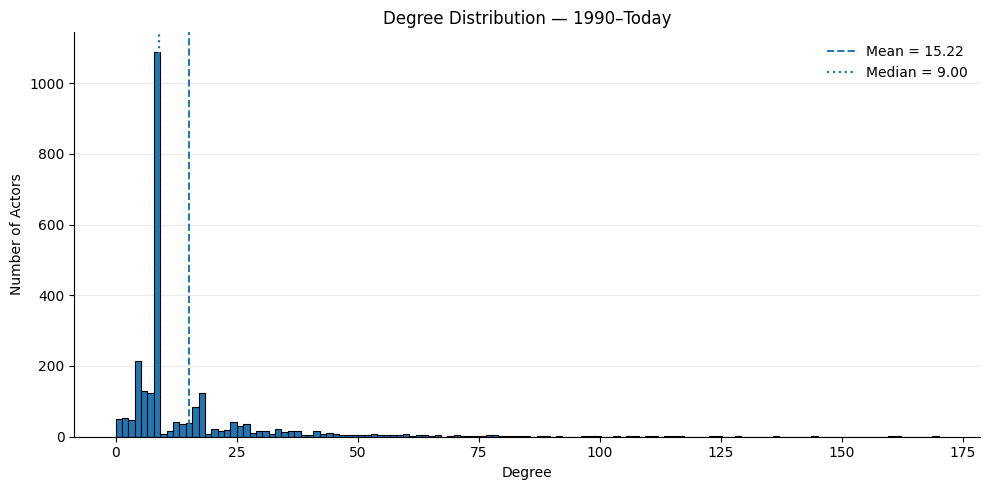

In [7]:
degree_distributions = {
    period_name: pd.Series(
        [
            degree
            for _, degree in graph.degree()
        ],
        name="degree"
    )
    for period_name, graph
    in period_graphs.items()
}

for period_name, degree_series in degree_distributions.items():
    values = degree_series.to_numpy()

    q1, q3 = np.percentile(
        values,
        [25, 75]
    )

    iqr = q3 - q1

    if iqr > 0:
        bin_width = (
            2
            * iqr
            / np.cbrt(len(values))
        )

        number_of_bins = max(
            8,
            int(np.ceil(
                (
                    values.max()
                    - values.min()
                )
                / bin_width
            ))
        )
    else:
        number_of_bins = 10

    fig, ax = plt.subplots(
        figsize=(10, 5)
    )

    ax.hist(
        values,
        bins=number_of_bins,
        edgecolor="black",
        linewidth=0.8
    )

    ax.axvline(
        values.mean(),
        linestyle="--",
        linewidth=1.4,
        label=f"Mean = {values.mean():.2f}"
    )

    ax.axvline(
        np.median(values),
        linestyle=":",
        linewidth=1.6,
        label=f"Median = {np.median(values):.2f}"
    )

    ax.set_title(
        f"Degree Distribution — {period_name}"
    )
    ax.set_xlabel("Degree")
    ax.set_ylabel("Number of Actors")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax.legend(frameon=False)

    plt.tight_layout()
    plt.show()

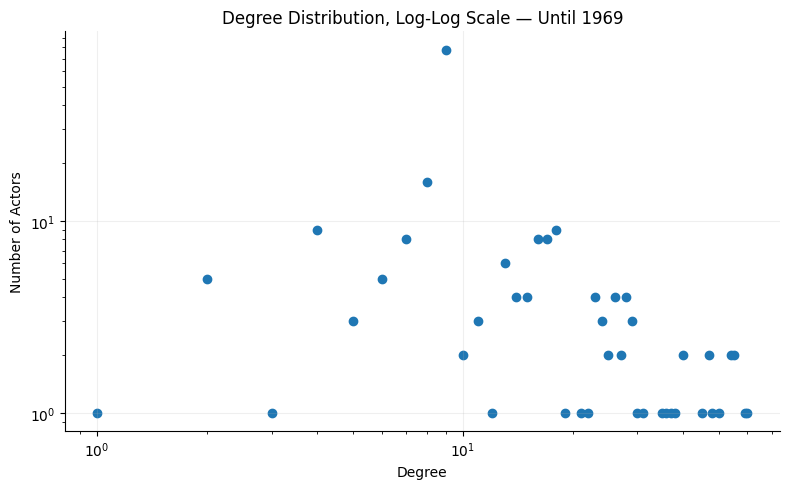

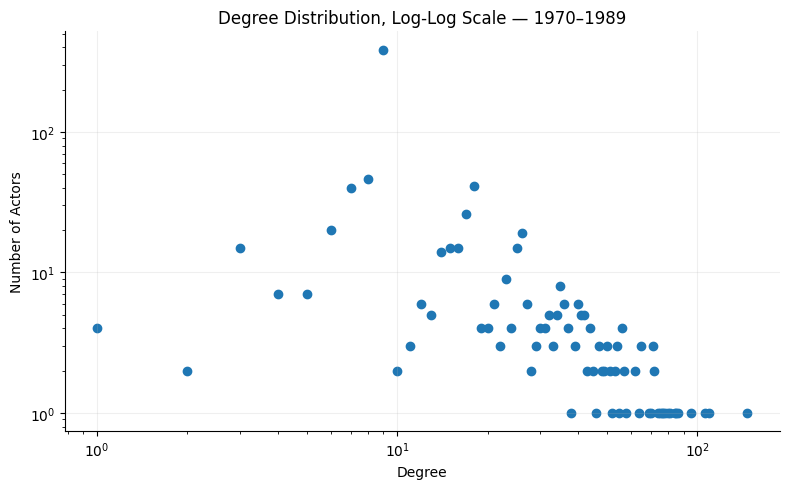

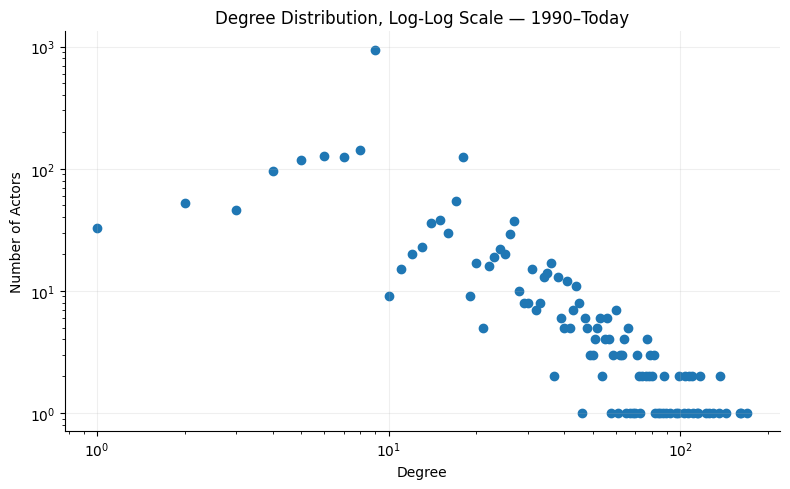

In [8]:
for period_name, degree_series in degree_distributions.items():
    degree_counts = (
        degree_series
        .value_counts()
        .sort_index()
    )

    degree_counts = degree_counts[
        degree_counts.index > 0
    ]

    fig, ax = plt.subplots(
        figsize=(8, 5)
    )

    ax.scatter(
        degree_counts.index,
        degree_counts.values
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(
        f"Degree Distribution, Log-Log Scale — {period_name}"
    )
    ax.set_xlabel("Degree")
    ax.set_ylabel("Number of Actors")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

### 8. Structural Comparison

Measures with different numerical scales are plotted separately so that each trend remains visible.

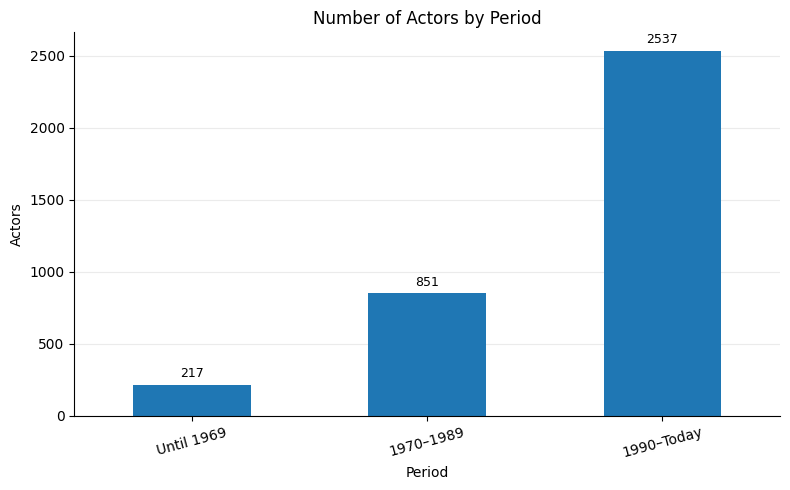

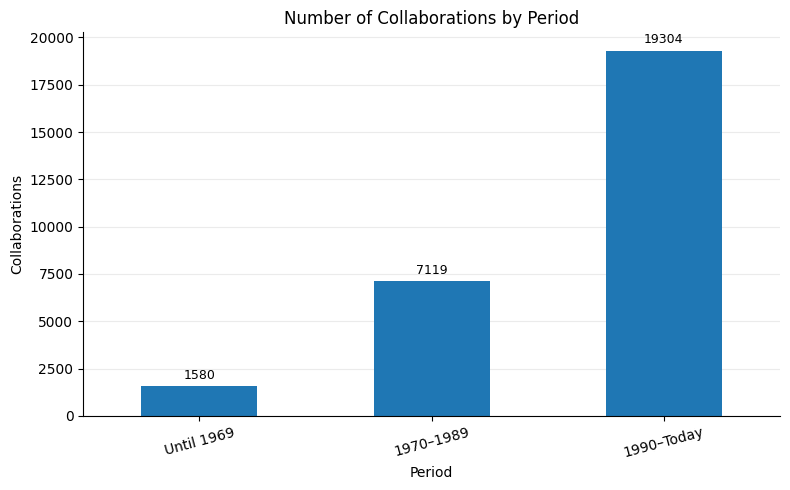

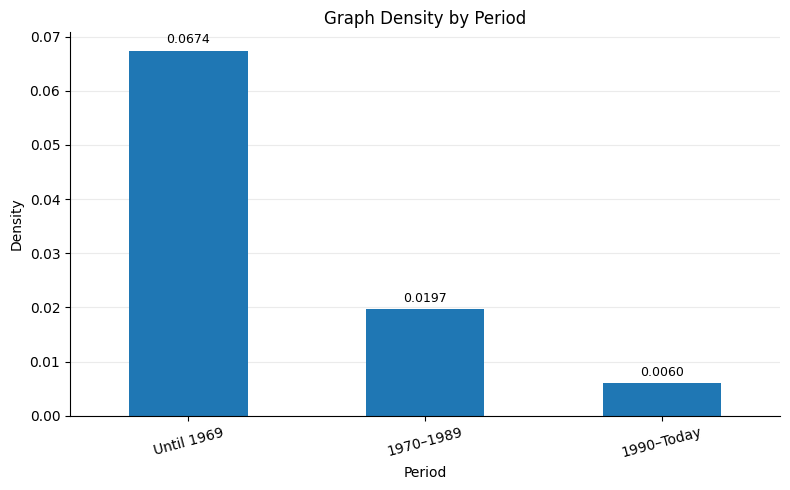

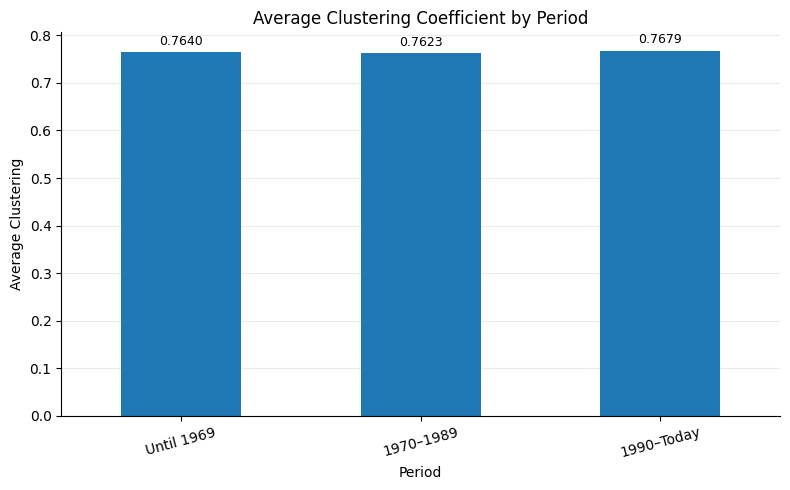

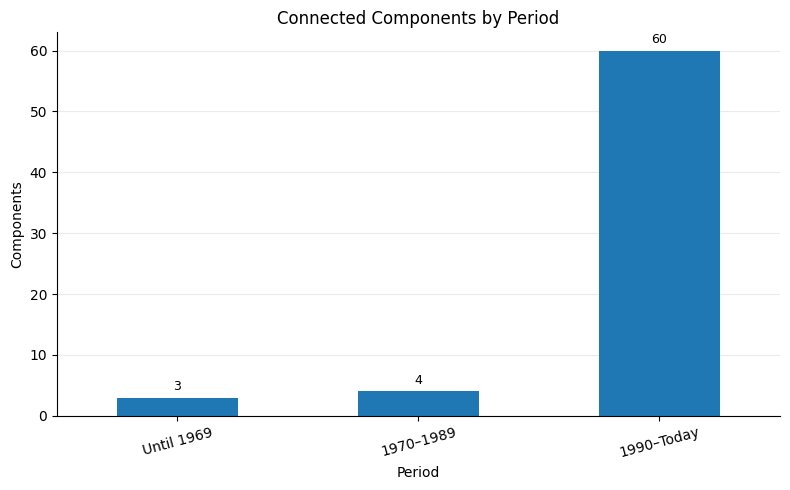

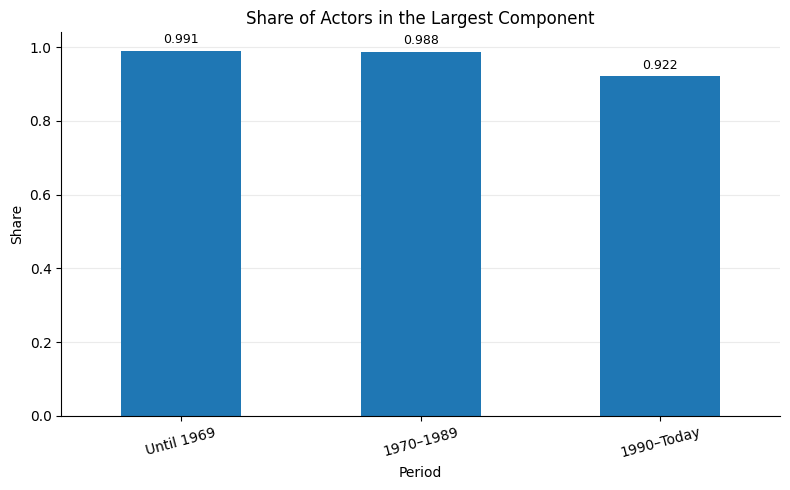

In [9]:
plot_specs = [
    (
        "nodes",
        "Number of Actors by Period",
        "Actors",
        0
    ),
    (
        "edges",
        "Number of Collaborations by Period",
        "Collaborations",
        0
    ),
    (
        "density",
        "Graph Density by Period",
        "Density",
        4
    ),
    (
        "average_clustering",
        "Average Clustering Coefficient by Period",
        "Average Clustering",
        4
    ),
    (
        "connected_components",
        "Connected Components by Period",
        "Components",
        0
    ),
    (
        "largest_component_share",
        "Share of Actors in the Largest Component",
        "Share",
        3
    )
]

for (
    column,
    title,
    ylabel,
    decimals
) in plot_specs:
    fig, ax = plt.subplots(
        figsize=(8, 5)
    )

    metrics_df[column].plot(
        kind="bar",
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel("Period")
    ax.set_ylabel(ylabel)
    ax.tick_params(
        axis="x",
        rotation=15
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

    add_bar_labels(
        ax,
        decimals=decimals
    )

    plt.tight_layout()
    plt.show()

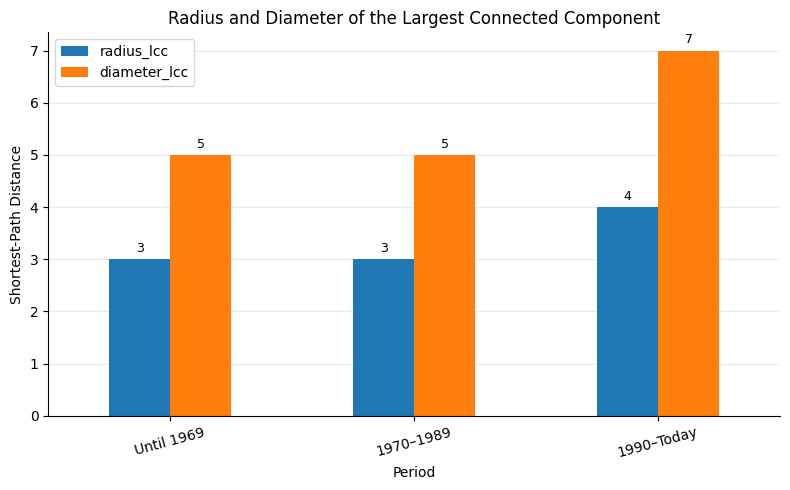

In [10]:
distance_metrics = metrics_df[
    [
        "radius_lcc",
        "diameter_lcc"
    ]
]

ax = distance_metrics.plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_title(
    "Radius and Diameter of the Largest Connected Component"
)
ax.set_xlabel("Period")
ax.set_ylabel("Shortest-Path Distance")
ax.tick_params(
    axis="x",
    rotation=15
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()

### 9. Most Connected Actors

In [11]:
top_degree_records = []

for period_name, graph in period_graphs.items():
    top_actors = sorted(
        graph.degree(),
        key=lambda item: item[1],
        reverse=True
    )[:10]

    for rank, (
        actor,
        degree
    ) in enumerate(
        top_actors,
        start=1
    ):
        top_degree_records.append({
            "period": period_name,
            "rank": rank,
            "actor": actor,
            "degree": degree
        })

top_degree_df = pd.DataFrame(
    top_degree_records
)

for period_name in PERIODS:
    print(f"\n{period_name}")

    display(
        top_degree_df[
            top_degree_df["period"].eq(
                period_name
            )
        ][
            [
                "rank",
                "actor",
                "degree"
            ]
        ]
    )


Until 1969


,rank,actor,degree
0,1,אבנר חזקיהו,60
1,2,בומבה צור,59
2,3,גילה אלמגור,55
3,4,אלישבע מיכאלי,55
4,5,גדעון זינגר,54
5,6,שייקה אופיר,54
6,7,אורי זוהר,50
7,8,אורי לוי,48
8,9,שייקה לוי,47
9,10,שרגא פרידמן,47



1970–1989


,rank,actor,degree
10,1,יוסף שילוח,147
11,2,זאב רווח,109
12,3,גבי עמרני,106
13,4,אריה אליאס,95
14,5,שייקה אופיר,86
15,6,משה איש כסית,85
16,7,גדעון זינגר,84
17,8,ז'אק כהן,81
18,9,יונה אליאן,80
19,10,יהודה אפרוני,78



1990–Today


,rank,actor,degree
20,1,משה איבגי,170
21,2,אלון אבוטבול,162
22,3,צחי גראד,160
23,4,אורי גבריאל,144
24,5,אלברט אילוז,137
25,6,ליאור אשכנזי,137
26,7,שמיל בן ארי,136
27,8,אסי דיין,129
28,9,יגאל עדיקא,125
29,10,שרון אלכסנדר,123


### 10. Conclusions

In [12]:
first_period = metrics_df.iloc[0]
middle_period = metrics_df.iloc[1]
last_period = metrics_df.iloc[-1]

print(
    "1. Network growth: "
    f"the number of actors increased from "
    f"{int(first_period['nodes'])} to "
    f"{int(last_period['nodes'])}, while collaborations increased from "
    f"{int(first_period['edges'])} to "
    f"{int(last_period['edges'])}."
)

print(
    "2. Density: "
    f"density decreased from "
    f"{first_period['density']:.4f} to "
    f"{last_period['density']:.4f}, because the number of possible actor pairs "
    f"grew faster than the number of observed collaborations."
)

print(
    "3. Clustering: "
    f"the average clustering coefficient remained high, ranging from "
    f"{metrics_df['average_clustering'].min():.4f} to "
    f"{metrics_df['average_clustering'].max():.4f}. "
    f"This indicates persistent collaboration in tightly connected groups."
)

print(
    "4. Connectivity: "
    f"the largest connected component contains "
    f"{last_period['largest_component_share']:.1%} of actors in the latest period, "
    f"compared with {first_period['largest_component_share']:.1%} in the earliest period."
)

print(
    "5. Degree structure: "
    f"the average degree changed from "
    f"{first_period['average_degree']:.2f} to "
    f"{last_period['average_degree']:.2f}, while the maximum degree increased from "
    f"{int(first_period['maximum_degree'])} to "
    f"{int(last_period['maximum_degree'])}. "
    f"This suggests a small number of increasingly central actors."
)

1. Network growth: the number of actors increased from 217 to 2537, while collaborations increased from 1580 to 19304.
2. Density: density decreased from 0.0674 to 0.0060, because the number of possible actor pairs grew faster than the number of observed collaborations.
3. Clustering: the average clustering coefficient remained high, ranging from 0.7623 to 0.7679. This indicates persistent collaboration in tightly connected groups.
4. Connectivity: the largest connected component contains 92.2% of actors in the latest period, compared with 99.1% in the earliest period.
5. Degree structure: the average degree changed from 14.56 to 15.22, while the maximum degree increased from 60 to 170. This suggests a small number of increasingly central actors.


### 11. Save Results

In [13]:
metrics_df.to_csv(
    "graph_metrics.csv",
    encoding="utf-8-sig"
)

comparison_df.to_csv(
    "graph_comparison.csv",
    encoding="utf-8-sig"
)

top_degree_df.to_csv(
    "top_degree_actors_by_period.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved:")
print("- graph_metrics.csv")
print("- graph_comparison.csv")
print("- top_degree_actors_by_period.csv")

Saved:
- graph_metrics.csv
- graph_comparison.csv
- top_degree_actors_by_period.csv
